In [9]:
from model_ranking import (
    load_h5,
    get_random_colors
)
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ov_raw_path = "/scratch/talks/data/Ovules/GT2x/test/N_294_final_crop_ds2.h5"
ov_raw_key = "raw"
ov_gt_key = "label_with_ignore"

In [3]:
path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P_fullslice/fw_model_Unet2/norm_50_950/gauss_a01-015/predictions/N_294_final_crop_ds2_predictions.h5"
segs = load_h5(path, "segmentation")
adarand_error = load_h5(path, "AdaRandError_consis")
MAP_scores = load_h5(path, "MAP_05_095")

In [4]:
nan_ids = np.where(np.isnan(adarand_error))[0]
print(len(nan_ids))

36


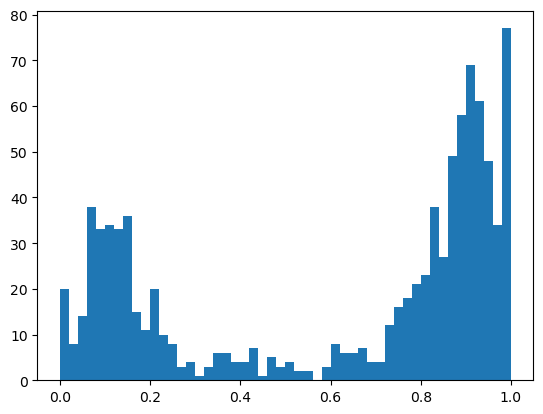

In [5]:
plt.hist(adarand_error.ravel(), bins=50)
plt.show()

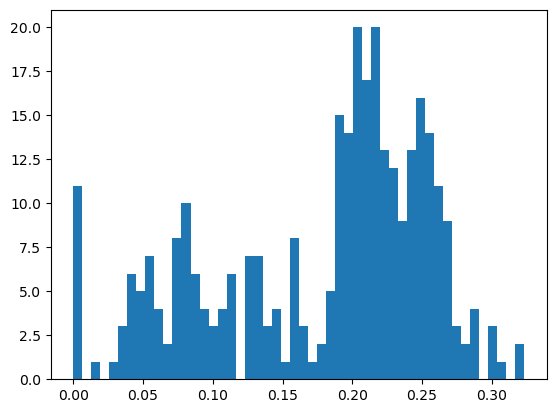

In [6]:
plt.hist(MAP_scores.ravel(), bins=50)
plt.show()

In [14]:
ARE_1 = np.where((1 - adarand_error[:, 0]== 1))[0]
print(len(ARE_1))

11


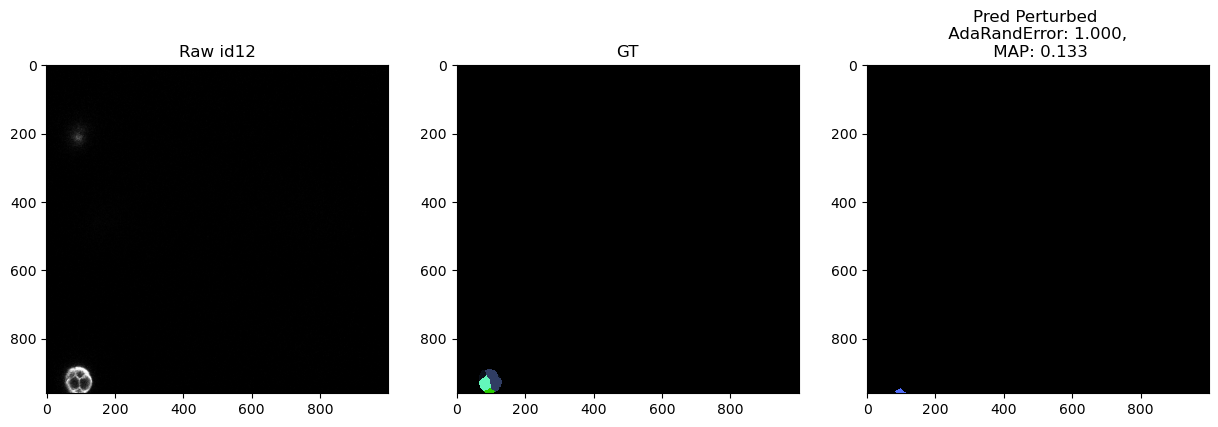

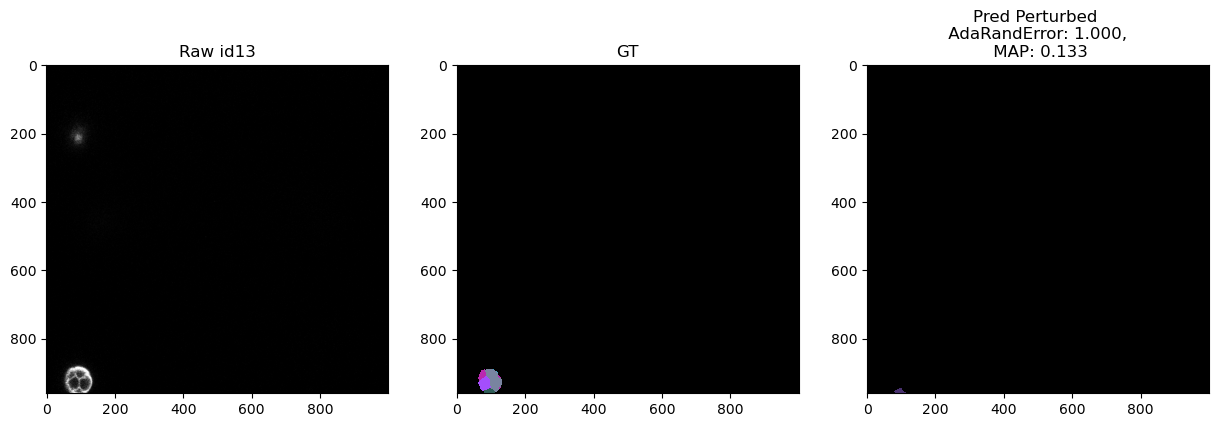

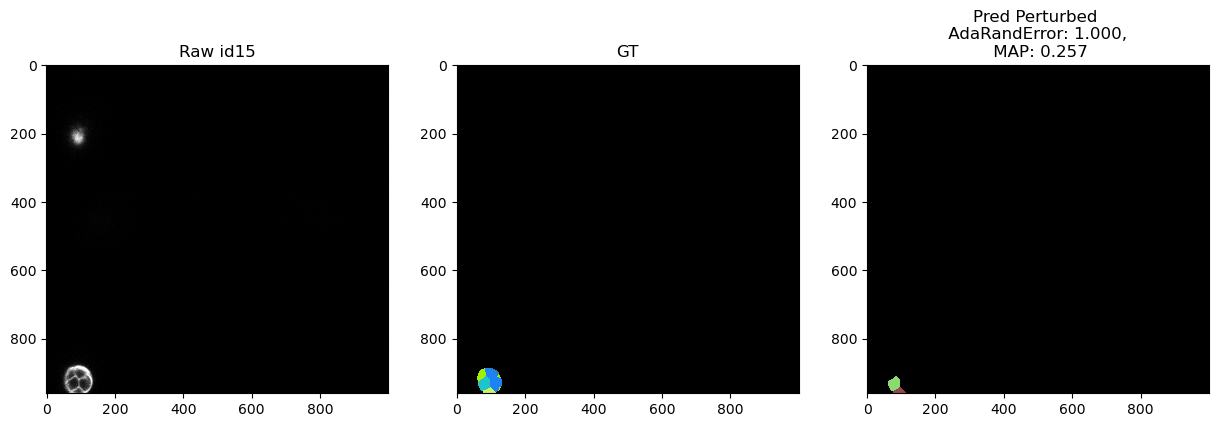

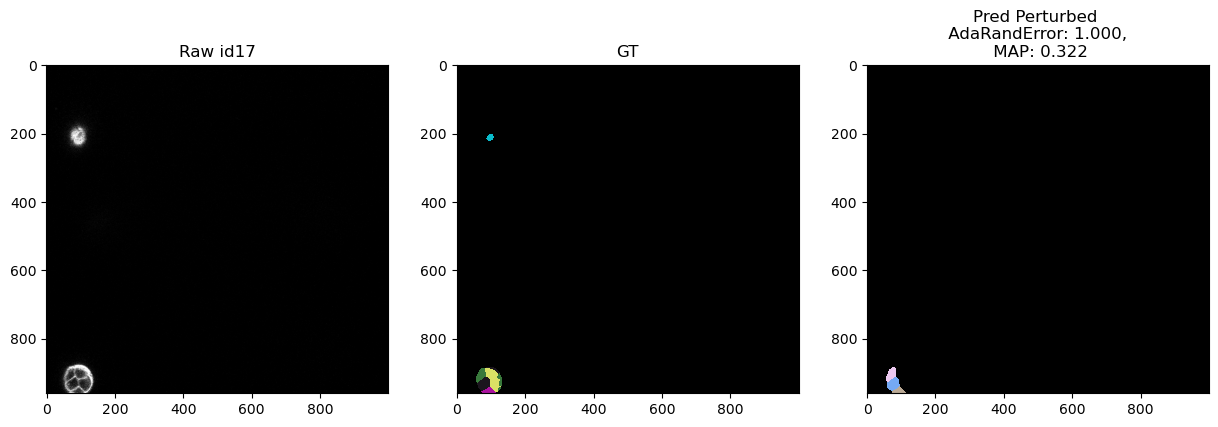

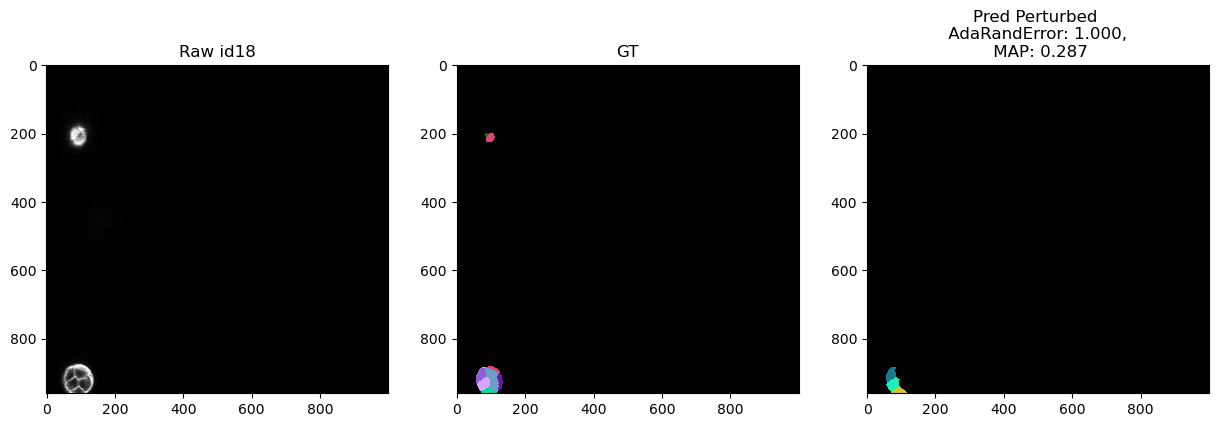

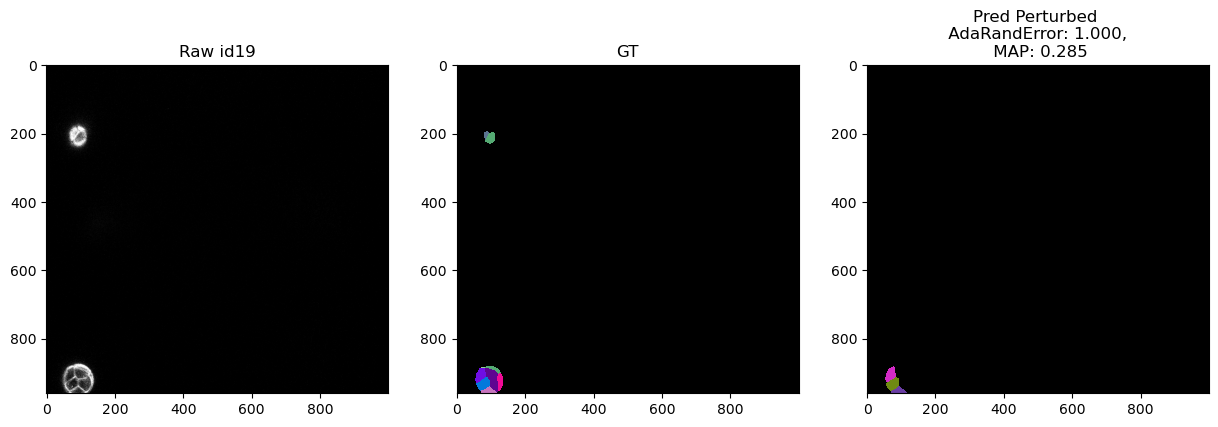

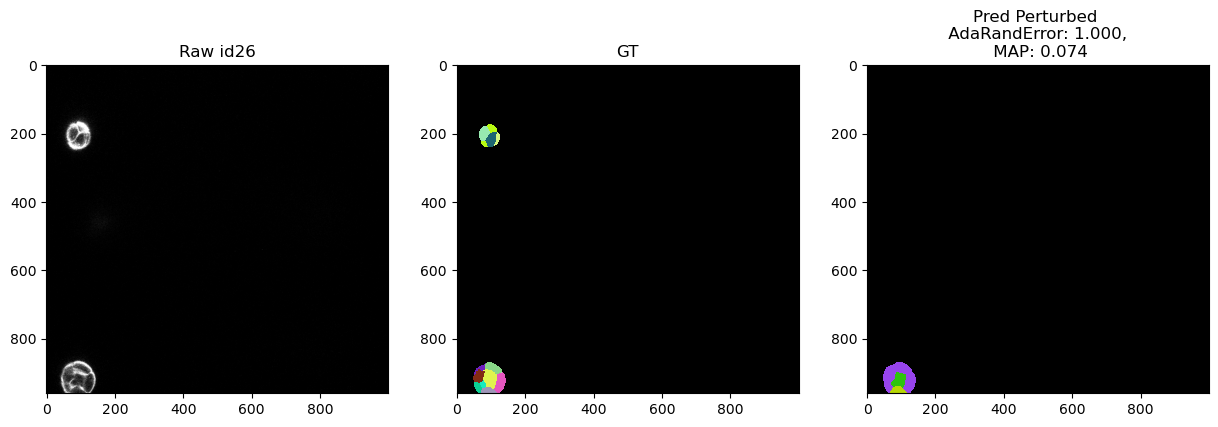

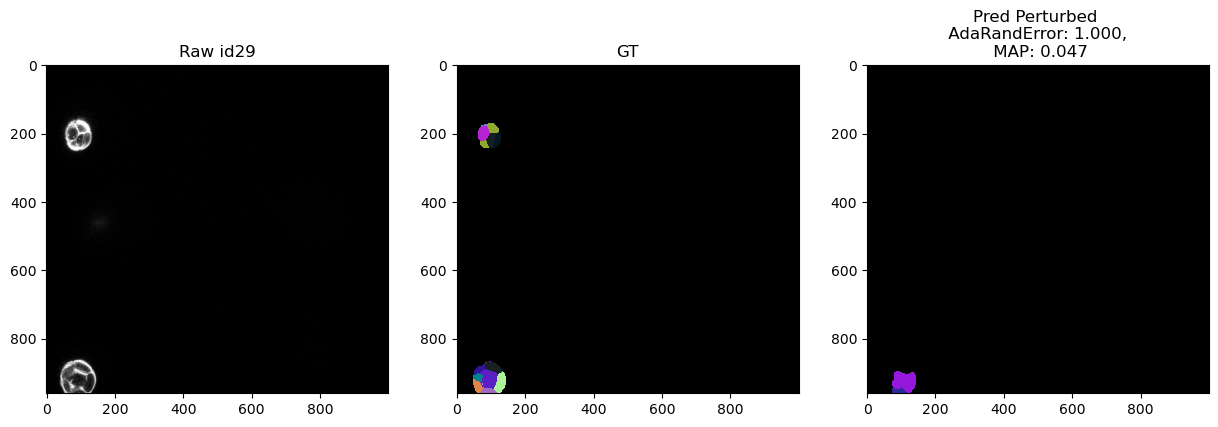

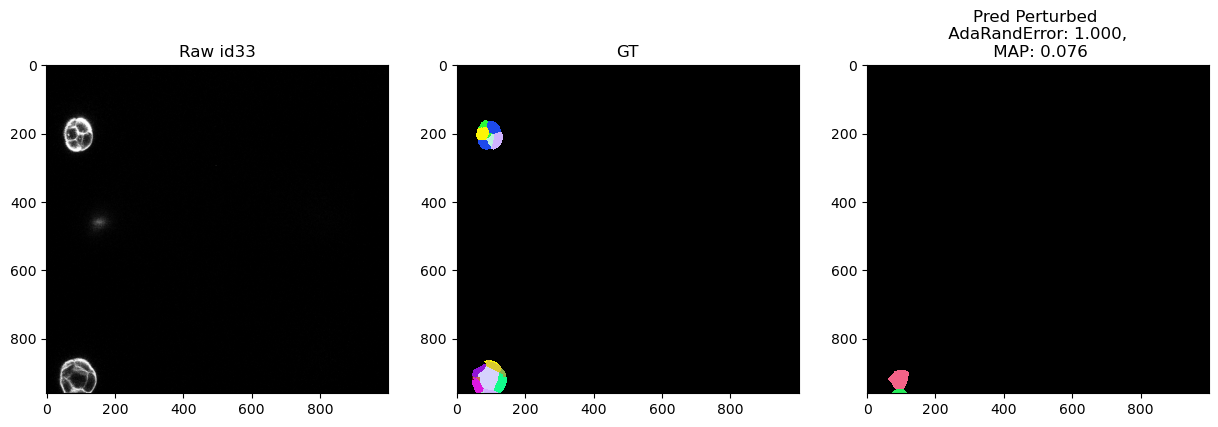

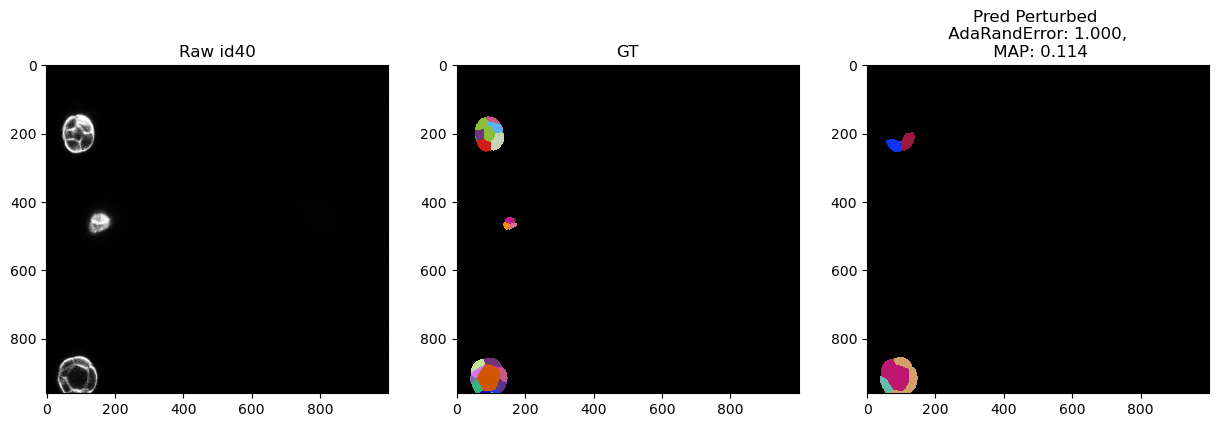

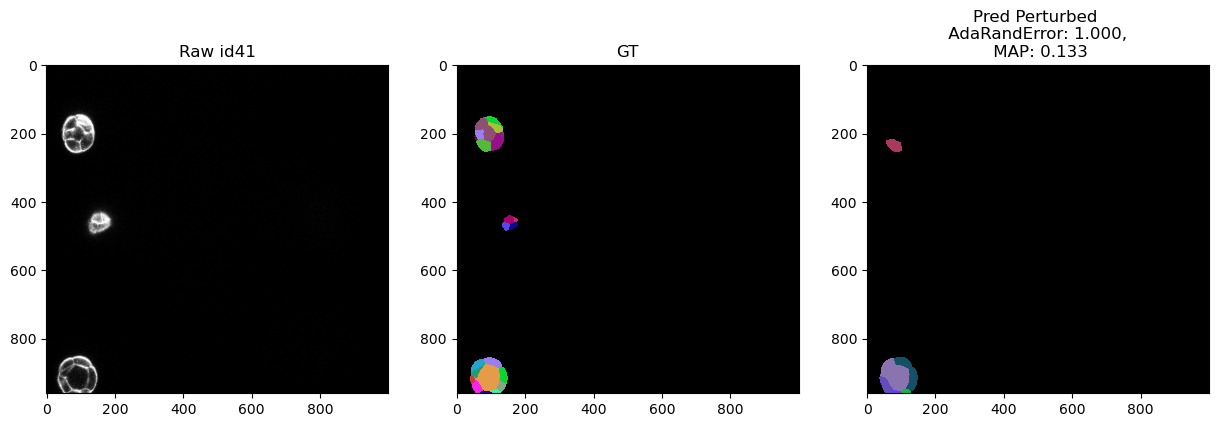

In [15]:
offset = 0
num=11
for i in ARE_1[offset: offset+num]:
    _, axs = plt.subplots(1,3, figsize=(15,5))
    raw = load_h5(ov_raw_path, ov_raw_key, select_index = i)
    gt = load_h5(ov_raw_path, ov_gt_key, select_index = i)
    axs[0].imshow(raw.squeeze(), cmap="gray")
    axs[0].set_title(f"Raw id{i}")
    axs[1].imshow(gt.squeeze(), cmap=get_random_colors(gt), interpolation='nearest')
    axs[1].set_title(f"GT")
    axs[2].imshow(segs[i].squeeze(), cmap=get_random_colors(segs[i]), interpolation='nearest')
    axs[2].set_title(f"Pred Perturbed \n AdaRandError: {1 - adarand_error[i, 0]:.3f}, \n MAP: {MAP_scores[i]:.3f}")
    plt.show()